_Trabajo Fin de Master_

_Máster Universitario en Inteligencia Artificial_

# Preprocesamiento, Entrenamiento y Comparativa de MobileNetv2, EfficientB0 y ResNet50

#Nota: Hemos dejado el código de llamado al entrenamiento de ResNet50, mas no ha sido ejecutado por falta de recurso computacional:
Equipo Disponible: 
- Entrenamiento en Local
- Mac OS 2015, 8Gb de RAM
- Intel i5 Doble Núcleo.
No cuenta con GPU disponible para distribuir entrenamiento.

### Importación
Aquí importamos los datos.

In [3]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Parche inmediato para certificados SSL en macOS
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import tensorflow as tf

from keras import layers, models, optimizers, utils
#from keras.preprocessing.image import ImageDataGenerator
from keras.applications import MobileNetV2, EfficientNetB0, ResNet50
from sklearn.metrics import classification_report, confusion_matrix





2026-09-09 01:40:31.956719: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
# ---------------------------------------------------------
# PREPROCESAMIENTO:
# ---------------------------------------------------------
# ---------------------------------------------------------
# 1. CONFIGURACIÓN Y CONSTANTES
# ---------------------------------------------------------

DATASET_DIR = "/Users/mansama18/Desktop/webdiseno/unir/TFM/v2/data/raw/" 

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 30 
LEARNING_RATE = 3e-4



In [ ]:


# 2. CARGA Y PREPROCESAMIENTO CON DATA AUGMENTATION
train_datagen = utils.image_dataset_from_directory(
    DATASET_DIR,
    labels='inferred',
    label_mode='categorical',
    batch_size=32,
    image_size=(224, 224)
)


train_ds = utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.3,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.3,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Clases detectadas ({num_classes}): {class_names}")


Found 764 files belonging to 6 classes.
Found 764 files belonging to 6 classes.
Using 535 files for training.
Found 764 files belonging to 6 classes.
Using 229 files for validation.
Clases detectadas (6): ['beau_s line', 'black line', 'clubbing', 'normal', 'onicomicosis', 'white spot']


In [ ]:
# ---------------------------------------------------------
# 3. FUNCIÓN DE CONSTRUCCIÓN DE MODELOS
# ---------------------------------------------------------
def build_transfer_model(model_name, num_classes):

    # 1. Entrada de la imagen RGB (224x224x3)
    inputs = tf.keras.layers.Input(shape=(224, 224, 3))
    
    # 2. BLOQUE DE DATA AUGMENTATION NATIVO (Seguro para datos biomédicos)
   
    x = tf.keras.layers.RandomFlip("horizontal")(inputs)
    x = tf.keras.layers.RandomRotation(0.08)(x)       # Rotaciones leves (±8%)
    x = tf.keras.layers.RandomZoom(0.1)(x)            # Zoom moderado (±10%)
    x = tf.keras.layers.RandomTranslation(0.05, 0.05)(x) # Desplazamiento leve

    if model_name == 'MobileNetV2':
        base_model = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_tensor=x, input_shape=(224,224,3))
    elif model_name == 'EfficientNetB0':
        base_model = tf.keras.applications.EfficientNetB0(weights='imagenet', include_top=False, input_tensor=x, input_shape=(224,224,3))
    #elif model_name == 'ResNet50':
        #base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    
    base_model.trainable = True
    for layers in base_model.layers[:-10]:
        layers.trainable = False
    
    #inputs = tf.keras.Input(shape=(224, 224, 3))
    #x = base_model(inputs, training=False)
    x = base_model.output
    pooled = tf.keras.layers.GlobalAveragePooling2D()(x)
    drops = tf.keras.layers.Dropout(0.3)(pooled)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(drops)
    
    model = tf.keras.models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model



In [8]:
# ---------------------------------------------------------
# 4. ENTRENAMIENTO COMPARATIVO (MobileNetV2, EfficientNetB0, ResNet50)
# ---------------------------------------------------------


architectures = ['MobileNetV2', 'EfficientNetB0']
results = []
best_model_obj = None
best_accuracy = 0.0
best_model_name = ""

for arch in architectures:
    print(f"\n==========================================")
    print(f" Entrenando Modelo: {arch}")
    print(f"==========================================")
    
    model = build_transfer_model(arch, num_classes)
    start_time = time.time()
    
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )
    
    elapsed_time = round(time.time() - start_time, 2)
    val_acc = history.history['val_accuracy'][-1]
    val_loss = history.history['val_loss'][-1]
    
    results.append({
        'Modelo': arch,
        'Accuracy Validación': round(val_acc * 100, 2),
        'Loss Validación': round(val_loss, 4),
        'Tiempo Entrenamiento (seg)': elapsed_time
    })
    
    if val_acc > best_accuracy:
        best_accuracy = val_acc
        best_model_obj = model
        best_model_name = arch




 Entrenando Modelo: MobileNetV2
Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.5682 - loss: 1.1607 - val_accuracy: 0.1048 - val_loss: 4.4409
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.7159 - loss: 0.7488 - val_accuracy: 0.1485 - val_loss: 3.5085
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accuracy: 0.7701 - loss: 0.6006 - val_accuracy: 0.2664 - val_loss: 2.0459
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.8243 - loss: 0.5168 - val_accuracy: 0.4672 - val_loss: 1.5113
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.8486 - loss: 0.4255 - val_accuracy: 0.6638 - val_loss: 0.9379
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.8336 - loss: 0.4360 - val_accuracy: 0.6725 - val_loss: 1.2311
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.8579 - loss: 0.3978 - val_accuracy: 0.7118 - val_loss: 1.2791
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.8673 - loss: 0.3999 -

In [12]:
# ---------------------------------------------------------
# 5. TABLA COMPARATIVA Y GUARDADO DEL MEJOR MODELO
# ---------------------------------------------------------
df_results = pd.DataFrame(results)
print("\n=== RESUMEN COMPARATIVO DE MODELOS ===")
print(df_results)
df_results.to_csv("tabla_comparativa_modelos.csv", index=False)

# Guardar el mejor modelo entrenado

best_model_obj.save(f"mejor_modelo_{best_model_name}.h5")
print(f"\nModelo guardado exitosamente como: mejor_modelo_{best_model_name}.h5")




=== RESUMEN COMPARATIVO DE MODELOS ===
           Modelo  Accuracy Validación  Loss Validación  \
0     MobileNetV2                65.07           3.6132   
1  EfficientNetB0                91.70           0.2670   

   Tiempo Entrenamiento (seg)  
0                     1580.71  
1                     2116.57  

Modelo guardado exitosamente como: mejor_modelo_EfficientNetB0.h5



Generando métricas detalladas para el mejor modelo: EfficientNetB0
PProcesando inferencias:


2026-09-09 03:27:33.061048: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



=== REPORTE DE CLASIFICACIÓN DENSIDAD ===
              precision    recall  f1-score     support
beau_s line    0.857143  0.800000  0.827586   15.000000
black line     0.857143  0.947368  0.900000   19.000000
clubbing       0.642857  0.900000  0.750000   10.000000
normal         0.986486  0.935897  0.960526  156.000000
onicomicosis   0.800000  0.800000  0.800000   15.000000
white spot     0.764706  0.928571  0.838710   14.000000
accuracy       0.917031  0.917031  0.917031    0.917031
macro avg      0.818056  0.885306  0.846137  229.000000
weighted avg   0.926503  0.917031  0.919641  229.000000


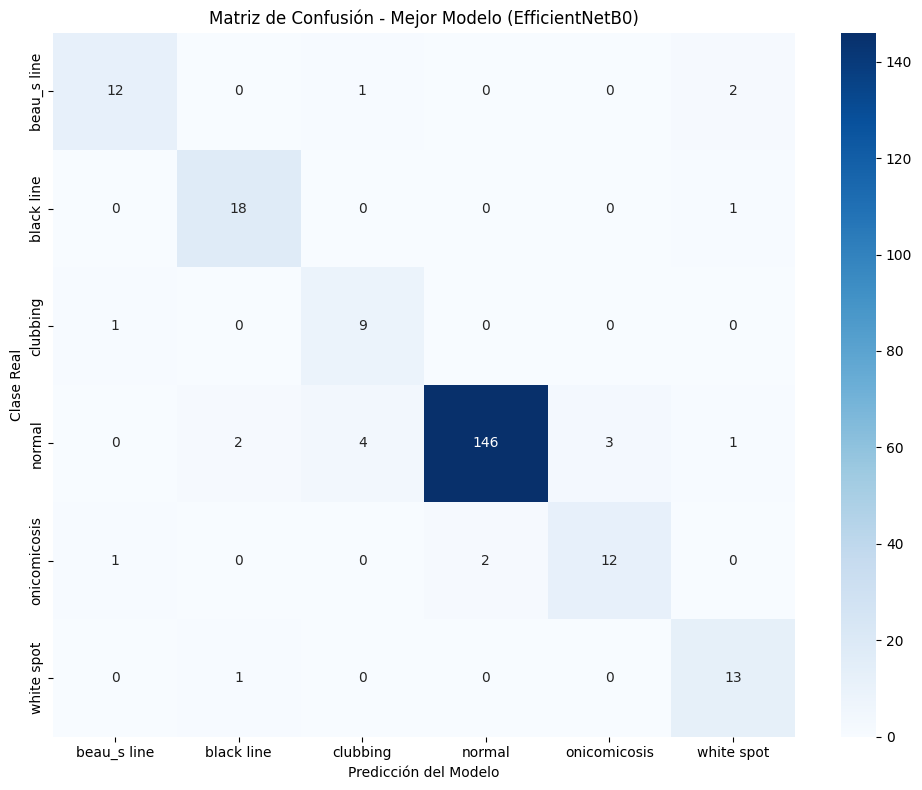


¡Proceso finalizado con éxito! Los archivos CSV e imágenes han sido guardados en la carpeta de tu Notebook.


In [13]:
# ---------------------------------------------------------
# 6. EVALUACIÓN Y MATRIZ DE CONFUSIÓN DEL MEJOR MODELO
# ---------------------------------------------------------
print(f"\nGenerando métricas detalladas para el mejor modelo: {best_model_name}")

#val_ds.reset()
y_true = []
y_pred = []


print('PProcesando inferencias:')
for images, labels in val_ds:
    predictions = best_model_obj.predict(images, verbose=0)
    y_true.extend(np.argmax(predictions, axis=1))
    y_pred.extend(np.argmax(labels.numpy(), axis=1))

# Reporte de Clasificación (Precision, Recall, F1-Score)
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
print("\n=== REPORTE DE CLASIFICACIÓN DENSIDAD ===")
print(df_report)
df_report.to_csv("reporte_clasificacion_detalle.csv")

# Matriz de Confusión Visual
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de Confusión - Mejor Modelo ({best_model_name})')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Clase Real')
plt.tight_layout()
plt.savefig("matriz_confusion_final.png", dpi=300)
plt.show()

print("\n¡Proceso finalizado con éxito! Los archivos CSV e imágenes han sido guardados en la carpeta de tu Notebook.")


In [ ]:
#GRAFICA DE CURVAS DE ENTRENAMIENTO DE MOBILENETV2 (Loss vs Accuracy)

plt.figure(figsize=(12,5))

#Gráfica de Exactitud (Accuracy)
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Entrenaiento (Train)', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validación (Val)', linewidth=2)
plt.title('Evolución de la Exactitud (Accuracy) - MobileNetV2')
plt.xlabel('Épocas')
plt.ylabel('Exactitud (Ratio 0-1)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

#Gráficos de Pérdida
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Entrenaiento (Train)', linewidth=2, color='red')
plt.plot(history.history['val_loss'], label='Validación (Val)', linewidth=2, linestyle='--', color='darked')
plt.title('Evolución de la Pérdida (Loss) - MobileNetV2')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Categorical Crossentropy)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.savefig('curvas_training_of_mobilenetv2.png')
plt.show()

print(f'Curvas de  Entrenamiento guardadas como curvas_training_of_mobilenetv2.png')



#Comparativa de los dos modelos

In [ ]:
#modelos

